In [11]:
from timeit import repeat
import random
import matplotlib.pyplot as plt

Cell below implements the quicksort algorithm using Lomuto's partitioning algorithm

In [12]:
# Insertion sort algorithm
def insertion_sort(arr: list):
    for i in range(1, len(arr)):
        key=arr[i]
        j=i-1
        while j>=0 and key<arr[j]:
            arr[j+1]=arr[j]
            j-=1
        arr[j+1]=key
    return arr

In [13]:
# Lomuto's partitioning algorithm with randomized pivot
def partition(arr, l, r):
    # randomize pivot
    rand_pivot = random.randint(l,r-1)
    arr[r], arr[rand_pivot] = arr[rand_pivot], arr[r]
    
    pivot=arr[r]
    
    i=l-1
    for j in range(l, r):
        if arr[j]<=pivot:
            i+=1
            arr[i], arr[j]= arr[j], arr[i]
    arr[i+1], arr[r] = arr[r], arr[i+1]
    return i+1

# Quicksort algorithm
def quicksort(arr,l=None,r=None):
    if l is None or r is None:
        l,r = 0,len(arr)-1
    elif l>=r:
        return
    
    i=partition(arr, l, r)
    quicksort(arr, l, i-1)
    quicksort(arr, i+1, r)
    return arr

In [14]:
def random_list(size):
    arr = [random.randint(0, size) for _ in range(size)]
    return arr

def partially_sorted_list(size):
    target_inversions = int((size * (size - 1) // 2) * 0.05)
    
    arr = []
    for num in range(size - 1, -1, -1):
        inv_to_add = min(target_inversions, len(arr))
        arr.insert(inv_to_add, num)
        target_inversions -= inv_to_add
        
    return arr

def fully_sorted_list(size):
    return sorted(random_list(size))

def reversed_sorted_list(size):
    arr = sorted(random_list(size))
    arr.reverse()
    return arr

In [15]:
sizes=[10**3, 5*10**3, 10**4, 5*10**4]
list_types=[
    "random_list", 
    "partially_sorted_list", 
    "fully_sorted_list", 
    "reversed_sorted_list"
]
timeit_number = 5

In [16]:
insertion_sort_results = {} # { [list_type]: { [size]: float } }

for list_type in list_types:
    insertion_sort_results[list_type]={}
    for size in sizes:
        setup_code = f"data = {list_type}({size})"
        stmt_code = "insertion_sort(data)"
        times = repeat(
            stmt=stmt_code,
            setup=setup_code,
            repeat=timeit_number,
            number=1,
            globals=globals()
        )
        insertion_sort_results[list_type][size] = sum(times)/timeit_number

insertion_sort_results

{'random_list': {1000: 0.017467383400071413,
  5000: 0.4245616500033066,
  10000: 1.7213481082057114,
  50000: 44.024612974998306},
 'partially_sorted_list': {1000: 0.0018085082003381104,
  5000: 0.04225080859614536,
  10000: 0.15989298339700325,
  50000: 4.040112083603162},
 'fully_sorted_list': {1000: 7.603339618071914e-05,
  5000: 0.0004217497946228832,
  10000: 0.0008306334086228162,
  50000: 0.004161824798211455},
 'reversed_sorted_list': {1000: 0.029619483405258506,
  5000: 0.8186011916026473,
  10000: 3.4082397249992935,
  50000: 87.16730585820042}}

In [17]:
quicksort_results = {} # { [list_type]: { [size]: float } }

for list_type in list_types:
    quicksort_results[list_type]={}
    for size in sizes:
        setup_code = f"data = {list_type}({size})"
        stmt_code = "quicksort(data)"
        times = repeat(
            stmt=stmt_code,
            setup=setup_code,
            repeat=timeit_number,
            number=1,
            globals=globals()
        )
        quicksort_results[list_type][size] = sum(times)/timeit_number

quicksort_results

{'random_list': {1000: 0.0010868749988730997,
  5000: 0.005704625201178715,
  10000: 0.011936966399662196,
  50000: 0.06528626699582674},
 'partially_sorted_list': {1000: 0.000820274802390486,
  5000: 0.004923791601322591,
  10000: 0.010397150204516948,
  50000: 0.05991140019032173},
 'fully_sorted_list': {1000: 0.0008653168042656034,
  5000: 0.005052849993808195,
  10000: 0.010869666596408933,
  50000: 0.061936408397741616},
 'reversed_sorted_list': {1000: 0.0008800998097285628,
  5000: 0.00518199999933131,
  10000: 0.01115639999625273,
  50000: 0.06297988339792937}}

In [18]:
titles_ru = {
    'random_list': 'Случайные данные',
    'partially_sorted_list': 'Частично отсортированные данные',
    'fully_sorted_list': 'Полностью отсортированные данные',
    'reversed_sorted_list': 'Отсортированные в обратном порядке данные'
}

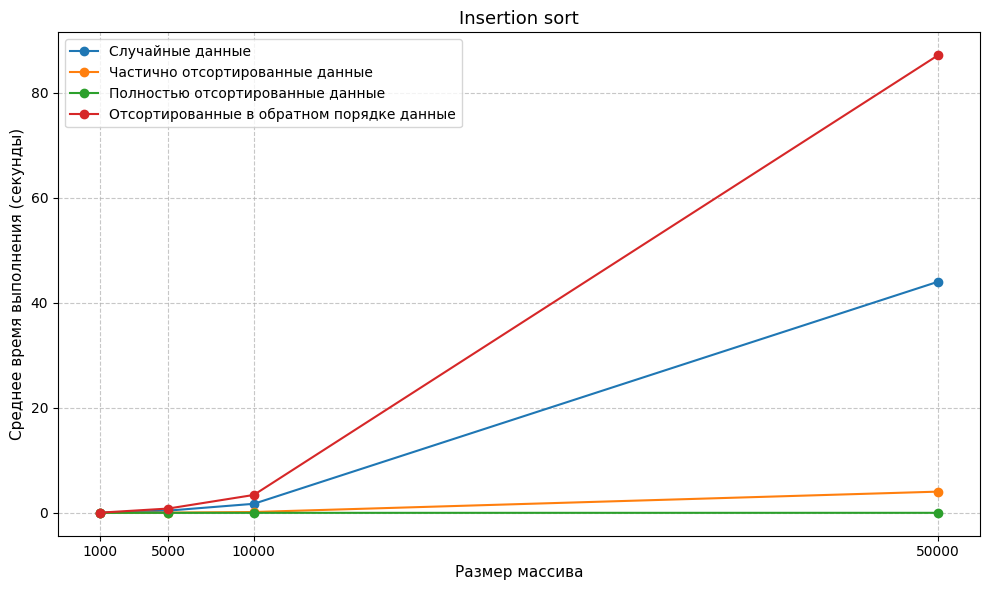

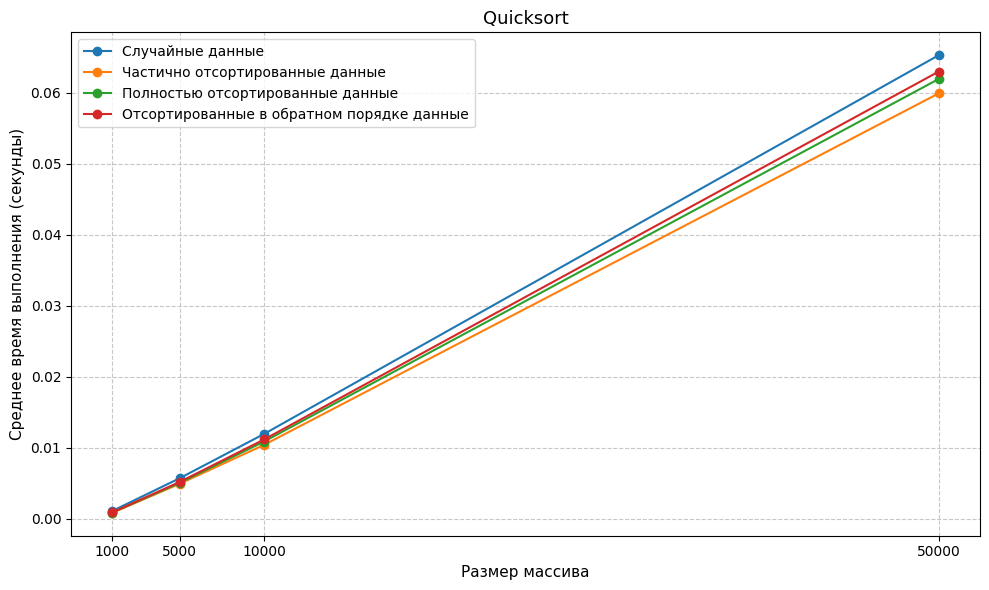

In [19]:
for results in [insertion_sort_results, quicksort_results]:
    plt.figure(figsize=(10, 6))

    for list_type, times in results.items():
        execution_times = list(times.values())
        plt.plot(sizes, execution_times, marker='o', label=titles_ru[list_type])

    plt.xlabel('Размер массива', fontsize=11)
    plt.ylabel('Среднее время выполнения (секунды)', fontsize=11)
    plt.title("Quicksort" if results is quicksort_results else "Insertion sort", fontsize=13)
    
    plt.xticks(sizes)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

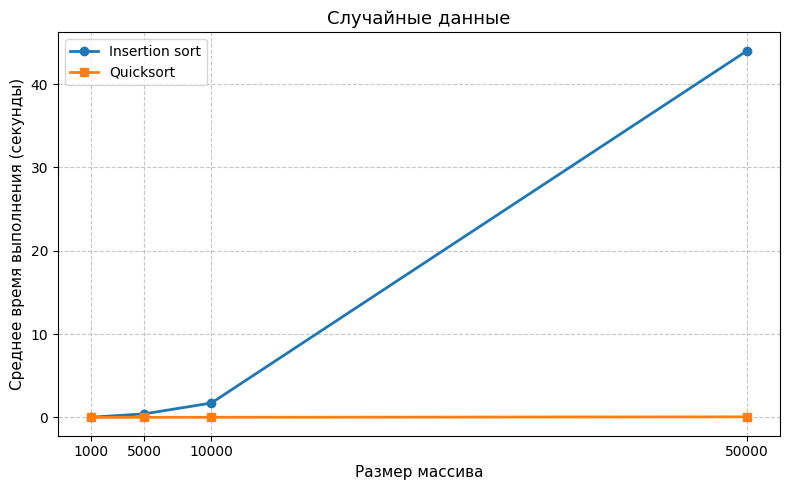

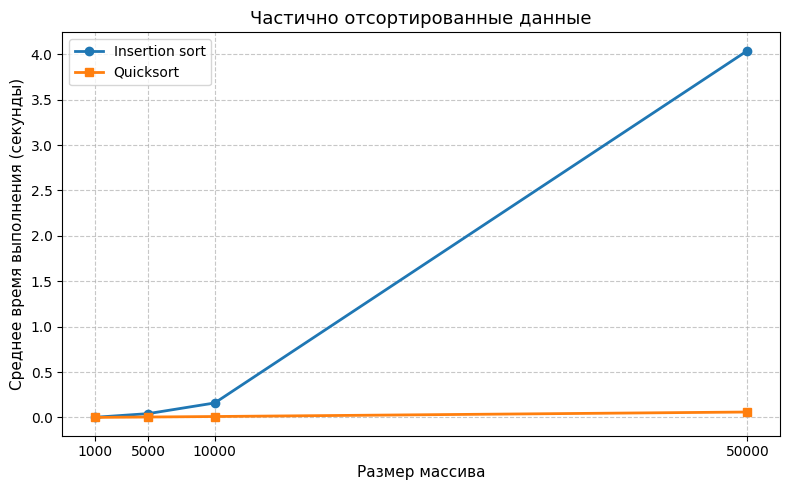

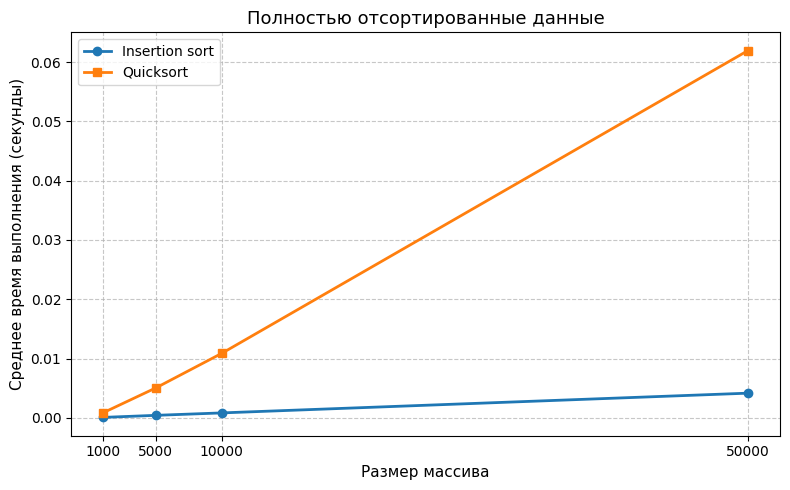

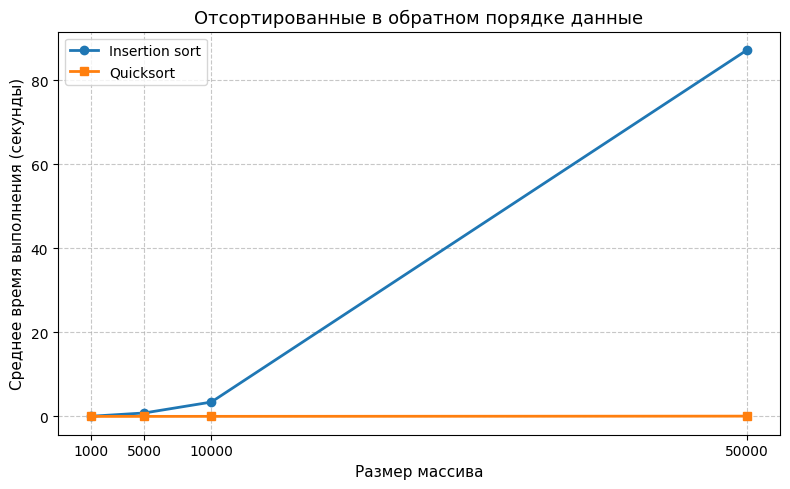

In [20]:
for list_type in list_types:
    plt.figure(figsize=(8, 5))
    
    times_is = list(insertion_sort_results[list_type].values())
    times_qs = list(quicksort_results[list_type].values())
    
    plt.plot(sizes, times_is, marker='o', label='Insertion sort', linewidth=2)
    plt.plot(sizes, times_qs, marker='s', label='Quicksort', linewidth=2)
    
    plt.xlabel('Размер массива', fontsize=11)
    plt.ylabel('Среднее время выполнения (секунды)', fontsize=11)
    plt.title(f'{titles_ru[list_type]}', fontsize=13)
    
    plt.xticks(sizes)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()